In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Autoencoder for Image Denoising using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary


In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Transform: Normalize and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
# Load MNIST dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.64MB/s]


In [ ]:
# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)


In [ ]:
# Define Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32) # Bottleneck layer
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid() # Output pixels should be between 0 and 1
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Flatten the image
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(-1, 1, 28, 28) # Reshape back to image format
        return x


In [ ]:
# Initialize model, loss function and optimizer
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Print model summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]         100,480
              ReLU-2                  [-1, 128]               0
            Linear-3                   [-1, 64]           8,256
              ReLU-4                   [-1, 64]               0
            Linear-5                   [-1, 32]           2,080
            Linear-6                   [-1, 64]           2,112
              ReLU-7                   [-1, 64]               0
            Linear-8                  [-1, 128]           8,320
              ReLU-9                  [-1, 128]               0
           Linear-10                  [-1, 784]         101,136
          Sigmoid-11                  [-1, 784]               0
Total params: 222,384
Trainable params: 222,384
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim


#Train the autoencoder

def train(model, loader, criterion, optimizer, epochs): # Corrected epochs-5 to epochs, as it's a parameter

    model.train() # Added indentation for the function body

    print("Name:Jagan J P")

    print("Register Number:212224230099")

    for epoch in range(epochs):

        running_loss = 0.0 # Corrected variable name: running loss -> running_loss

        for images, _ in loader: # Added _ to unpack labels from loader output

            images = images.to(device) # Added assignment operator =

            noisy_images = add_noise(images).to(device) # Added assignment operator =

            #Forward pass

            outputs = model(noisy_images) # Added assignment operator =

            loss = criterion(outputs, images) # Added assignment operator =

            #Backward pass and optimization

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item() # Corrected variable name and added += for accumulation

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {(running_loss/len(loader)):.4f}") # Fixed f-string formatting

In [23]:
# Evaluate and visualize
def visualize_denoising(model, loader, num_images=10):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)
            outputs = model(noisy_images)
            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print("Name:Jagan J P")
    print("Register Number:212224230099")
    plt.figure(figsize=(18, 6))
    for i in range(num_images):
        # Original
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title("Original")
        plt.axis("off")

        # Noisy
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        ax.set_title("Noisy")
        plt.axis("off")

        # Denoised
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.set_title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Name:Jagan J P
Register Number:212224230099
Epoch [1/5], Loss: 0.0269
Epoch [2/5], Loss: 0.0256
Epoch [3/5], Loss: 0.0244
Epoch [4/5], Loss: 0.0236
Epoch [5/5], Loss: 0.0228
Name:Jagan J P
Register Number:212224230099


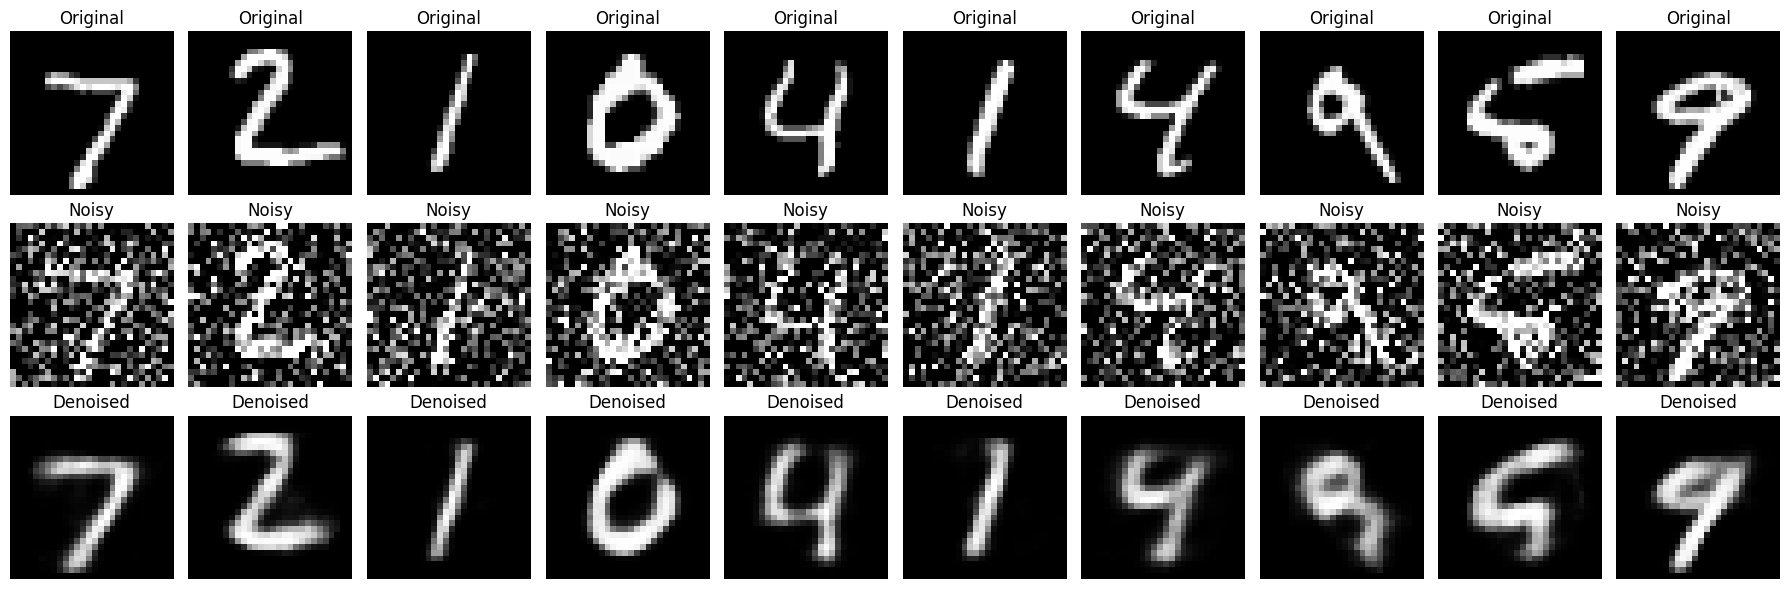

In [24]:
# Run training and visualization
train(model, train_loader, criterion, optimizer, epochs=5)
visualize_denoising(model, test_loader)